# 05 - Object Detection

## AI-Powered Runway FOD Detection & Safety Alert System

### Objective

In this notebook we convert the original FOD-A Pascal VOC annotations into YOLO format and train a YOLO object-detection baseline.

The workflow is:

```text
FOD-A Pascal VOC
        ↓
Read annotations
        ↓
Create class mapping
        ↓
Image-level train / validation / test split
        ↓
Pascal VOC XML → YOLO TXT
        ↓
Verify converted annotations visually
        ↓
Create data.yaml
        ↓
Train YOLO object detector
        ↓
Validate
        ↓
Run test predictions
        ↓
Save best model
```

### Important

The original FOD-A filenames contain leading zeros, for example:

```text
000000.jpg
010140.jpg
```

Therefore this notebook always uses the original `filename` column from `fod_annotations.csv`.

We do **not** build image paths from numeric `image_id`, because pandas may read `010140` as `10140` and remove the leading zero.


## 1. Import Libraries

In [64]:
from pathlib import Path
import shutil
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split

from ultralytics import YOLO


## 2. Locate the Project Root

In [65]:
# The notebook can be launched from either the project root
# or the notebooks directory.

VOC_RELATIVE_PATH = Path(
    "data",
    "raw",
    "FODPascalVOCFormat-V.2.1",
    "VOC2007"
)

possible_roots = [
    Path.cwd(),
    Path.cwd().parent
]

PROJECT_ROOT = None

for candidate_root in possible_roots:

    if (candidate_root / VOC_RELATIVE_PATH).exists():
        PROJECT_ROOT = candidate_root.resolve()
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project root. "
        "Expected FOD-A dataset at: "
        f"<project_root>/{VOC_RELATIVE_PATH}"
    )

print("Project root:", PROJECT_ROOT)


Project root: D:\Projects\AI Runway FOD Detection


## 3. Define Project Paths

In [66]:
VOC_ROOT = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "FODPascalVOCFormat-V.2.1"
    / "VOC2007"
)

IMAGE_DIR = VOC_ROOT / "JPEGImages"
ANNOTATION_DIR = VOC_ROOT / "Annotations"
IMAGESETS_DIR = VOC_ROOT / "ImageSets" / "Main"

PROCESSED_ANNOTATIONS = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "fod_annotations.csv"
)

YOLO_DATASET_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "yolo_dataset"
)

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

MODEL_DIR = PROJECT_ROOT / "models"

print("VOC root:", VOC_ROOT)
print("Image directory:", IMAGE_DIR)
print("Annotation directory:", ANNOTATION_DIR)
print("Processed annotations:", PROCESSED_ANNOTATIONS)
print("YOLO dataset:", YOLO_DATASET_DIR)
print("Artifacts:", ARTIFACTS_DIR)
print("Models:", MODEL_DIR)


VOC root: D:\Projects\AI Runway FOD Detection\data\raw\FODPascalVOCFormat-V.2.1\VOC2007
Image directory: D:\Projects\AI Runway FOD Detection\data\raw\FODPascalVOCFormat-V.2.1\VOC2007\JPEGImages
Annotation directory: D:\Projects\AI Runway FOD Detection\data\raw\FODPascalVOCFormat-V.2.1\VOC2007\Annotations
Processed annotations: D:\Projects\AI Runway FOD Detection\data\processed\fod_annotations.csv
YOLO dataset: D:\Projects\AI Runway FOD Detection\data\processed\yolo_dataset
Artifacts: D:\Projects\AI Runway FOD Detection\artifacts
Models: D:\Projects\AI Runway FOD Detection\models


## 4. Validate Required Paths

In [67]:
required_paths = {
    "VOC root": VOC_ROOT,
    "Images": IMAGE_DIR,
    "Annotations": ANNOTATION_DIR,
    "ImageSets": IMAGESETS_DIR,
    "Processed annotation CSV": PROCESSED_ANNOTATIONS,
}

for name, path in required_paths.items():

    print(
        f"{name}: "
        f"{'FOUND' if path.exists() else 'MISSING'}"
    )

missing_paths = [
    str(path)
    for path in required_paths.values()
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "One or more required project paths are missing:\n"
        + "\n".join(missing_paths)
    )


VOC root: FOUND
Images: FOUND
Annotations: FOUND
ImageSets: FOUND
Processed annotation CSV: FOUND


## 5. Load the Processed Annotation Data

In [68]:
df = pd.read_csv(
    PROCESSED_ANNOTATIONS
)

# Keep the original filename exactly as stored in the processed CSV.
df["filename"] = df["filename"].astype(str)

print("Shape:", df.shape)
print("Unique images:", df["image_id"].nunique())
print("Unique classes:", df["class_name"].nunique())
print()

print("Split distribution:")
print(df["split"].value_counts(dropna=False))

df.head()


Shape: (34472, 25)
Unique images: 33793
Unique classes: 31

Split distribution:
split
trainval      25789
test           8613
unassigned       70
Name: count, dtype: int64


,image_id,filename,image_path,annotation_path,split,width,height,class_name,xmin,ymin,...,pose,track_id,keyframe,weather_label,light_label,image_exists,x_center,y_center,box_width,box_height
0,0,000000.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,trainval,300,300,Battery,138.2219,104.2833,...,Unspecified,0,True,Wet,Dim,True,0.482771,0.421051,0.044062,0.14688
1,1,000001.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,trainval,300,300,Battery,138.2422,104.7611,...,Unspecified,0,False,Wet,Dim,True,0.482841,0.422644,0.044068,0.14688
2,2,000002.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,trainval,300,300,Battery,138.2641,105.2389,...,Unspecified,0,False,Wet,Dim,True,0.482911,0.424236,0.044062,0.14688
3,3,000003.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,trainval,300,300,Battery,138.2844,105.7167,...,Unspecified,0,False,Wet,Dim,True,0.482979,0.425829,0.044063,0.14688
4,4,000004.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,trainval,300,300,Battery,138.3047,106.1945,...,Unspecified,0,False,Wet,Dim,True,0.483047,0.427417,0.044062,0.14687


## 6. Create the YOLO Class Mapping

YOLO labels use numeric class IDs.

The mapping is created once and then used consistently for every annotation:

```text
FOD class name → numeric class ID
```

The class list is sorted so the mapping is deterministic.


In [69]:
classes = sorted(
    df["class_name"]
    .dropna()
    .unique()
)

class_to_id = {
    class_name: class_id
    for class_id, class_name in enumerate(classes)
}

id_to_class = {
    class_id: class_name
    for class_name, class_id in class_to_id.items()
}

NUM_CLASSES = len(classes)

print("Number of classes:", NUM_CLASSES)
print()

for class_id, class_name in id_to_class.items():
    print(
        class_id,
        "->",
        class_name
    )


Number of classes: 31

0 -> AdjustableClamp
1 -> AdjustableWrench
2 -> Battery
3 -> Bolt
4 -> BoltNutSet
5 -> BoltWasher
6 -> ClampPart
7 -> Cutter
8 -> FuelCap
9 -> Hammer
10 -> Hose
11 -> Label
12 -> LuggagePart
13 -> LuggageTag
14 -> MetalPart
15 -> MetalSheet
16 -> Nail
17 -> Nut
18 -> PaintChip
19 -> Pen
20 -> PlasticPart
21 -> Pliers
22 -> Rock
23 -> Screw
24 -> Screwdriver
25 -> SodaCan
26 -> Tape
27 -> Washer
28 -> Wire
29 -> Wood
30 -> Wrench


## 7. Create Image-Level Train / Validation / Test Splits

The FOD-A source provides `trainval.txt` and `test.txt`.

We keep all images from the official `test` split untouched.

The official `trainval` images are divided into:

```text
80% train
20% validation
```

The split is done using **unique image IDs**, not annotation rows. This is important because one image can contain multiple FOD objects.


In [70]:
trainval_images = sorted(
    df.loc[
        df["split"] == "trainval",
        "image_id"
    ]
    .drop_duplicates()
    .tolist()
)

test_images = sorted(
    df.loc[
        df["split"] == "test",
        "image_id"
    ]
    .drop_duplicates()
    .tolist()
)

train_images, val_images = train_test_split(
    trainval_images,
    test_size=0.20,
    random_state=42
)

train_images = sorted(train_images)
val_images = sorted(val_images)
test_images = sorted(test_images)

print("Train images:", len(train_images))
print("Validation images:", len(val_images))
print("Test images:", len(test_images))

print()
print(
    "Total selected images:",
    len(train_images) + len(val_images) + len(test_images)
)

print(
    "Trainval images in source:",
    len(trainval_images)
)


Train images: 20235
Validation images: 5059
Test images: 8429

Total selected images: 33723
Trainval images in source: 25294


## 8. Test the Original Filename Handling

This check exists specifically to prevent the leading-zero filename problem.

We take an image ID from the train split and get the real filename from the dataframe.


In [71]:
sample_image_id = train_images[0]

sample_rows = df[
    df["image_id"] == sample_image_id
]

if sample_rows.empty:
    raise ValueError(
        f"No annotation row found for image ID {sample_image_id}"
    )

sample_row = sample_rows.iloc[0]

sample_filename = str(
    sample_row["filename"]
)

sample_annotation_filename = Path(
    sample_row["annotation_path"]
).name

sample_image_source = (
    IMAGE_DIR
    / sample_filename
)

sample_xml_source = (
    ANNOTATION_DIR
    / sample_annotation_filename
)

print("Sample image ID:", sample_image_id)
print("Original image filename:", sample_filename)
print("Original annotation filename:", sample_annotation_filename)
print()
print("Image exists:", sample_image_source.exists())
print("Annotation exists:", sample_xml_source.exists())


Sample image ID: 0
Original image filename: 000000.jpg
Original annotation filename: 000000.xml

Image exists: True
Annotation exists: True


## 9. Understand the YOLO Annotation Format

Pascal VOC stores a bounding box like:

```text
xmin
ymin
xmax
ymax
```

YOLO stores the same box as:

```text
class_id
x_center
y_center
box_width
box_height
```

The four box values are normalized between 0 and 1.


## 10. Convert Pascal VOC Bounding Box to YOLO Format

In [72]:
def convert_box_to_yolo(
    xmin,
    ymin,
    xmax,
    ymax,
    image_width,
    image_height
):

    x_center = (
        (xmin + xmax) / 2
    ) / image_width

    y_center = (
        (ymin + ymax) / 2
    ) / image_height

    box_width = (
        xmax - xmin
    ) / image_width

    box_height = (
        ymax - ymin
    ) / image_height

    return (
        x_center,
        y_center,
        box_width,
        box_height
    )


## 11. Test One Bounding-Box Conversion

In [73]:
with Image.open(
    sample_image_source
) as image:

    image_width, image_height = image.size

tree = ET.parse(
    sample_xml_source
)

root = tree.getroot()

object_count = 0

for object_element in root.findall("object"):

    class_name = (
        object_element.findtext("name")
        or ""
    ).strip()

    bbox = object_element.find("bndbox")

    xmin = float(
        bbox.findtext("xmin")
    )

    ymin = float(
        bbox.findtext("ymin")
    )

    xmax = float(
        bbox.findtext("xmax")
    )

    ymax = float(
        bbox.findtext("ymax")
    )

    yolo_box = convert_box_to_yolo(
        xmin,
        ymin,
        xmax,
        ymax,
        image_width,
        image_height
    )

    class_id = class_to_id[class_name]

    print(
        "Class:",
        class_name,
        "| Class ID:",
        class_id,
        "| YOLO box:",
        yolo_box
    )

    object_count += 1

print()
print("Objects found in sample XML:", object_count)


Class: Battery | Class ID: 2 | YOLO box: (0.48277083333333337, 0.4210508333333333, 0.04406233333333328, 0.14687966666666663)

Objects found in sample XML: 1


## 12. Create a Complete YOLO Label

Each object in the Pascal VOC XML becomes one line in the YOLO `.txt` file.

The function below uses the existing class mapping and writes six-decimal normalized coordinates.


In [74]:
def create_yolo_label(xml_path):

    tree = ET.parse(xml_path)

    root = tree.getroot()

    size = root.find("size")

    if size is None:
        raise ValueError(
            f"Image size information missing in: {xml_path}"
        )

    image_width = float(
        size.findtext("width")
    )

    image_height = float(
        size.findtext("height")
    )

    if image_width <= 0 or image_height <= 0:
        raise ValueError(
            f"Invalid image dimensions in: {xml_path}"
        )

    label_lines = []

    for object_element in root.findall("object"):

        class_name = (
            object_element.findtext("name")
            or ""
        ).strip()

        if class_name not in class_to_id:
            continue

        bbox = object_element.find("bndbox")

        if bbox is None:
            continue

        xmin = float(
            bbox.findtext("xmin")
        )

        ymin = float(
            bbox.findtext("ymin")
        )

        xmax = float(
            bbox.findtext("xmax")
        )

        ymax = float(
            bbox.findtext("ymax")
        )

        if xmax <= xmin or ymax <= ymin:
            continue

        x_center, y_center, box_width, box_height = (
            convert_box_to_yolo(
                xmin,
                ymin,
                xmax,
                ymax,
                image_width,
                image_height
            )
        )

        class_id = class_to_id[class_name]

        label_lines.append(
            f"{class_id} "
            f"{x_center:.6f} "
            f"{y_center:.6f} "
            f"{box_width:.6f} "
            f"{box_height:.6f}"
        )

    return label_lines


## 13. Test the Complete YOLO Label

In [75]:
sample_label_lines = create_yolo_label(
    sample_xml_source
)

print(
    "Number of labels:",
    len(sample_label_lines)
)

print()

for line in sample_label_lines:
    print(line)


Number of labels: 1

2 0.482771 0.421051 0.044062 0.146880


## 14. Reset the Generated YOLO Dataset

This cell deletes only the generated folder:

```text
data/processed/yolo_dataset
```

It does **not** touch the original FOD-A data.

The dataset is rebuilt from scratch so no old incorrectly named files remain.


In [76]:
RESET_YOLO_DATASET = True

if RESET_YOLO_DATASET and YOLO_DATASET_DIR.exists():
    shutil.rmtree(
        YOLO_DATASET_DIR
    )

for split in [
    "train",
    "val",
    "test"
]:

    (
        YOLO_DATASET_DIR
        / "images"
        / split
    ).mkdir(
        parents=True,
        exist_ok=True
    )

    (
        YOLO_DATASET_DIR
        / "labels"
        / split
    ).mkdir(
        parents=True,
        exist_ok=True
    )

print(
    "YOLO dataset folders are ready."
)


YOLO dataset folders are ready.


## 15. Convert One Image Split to YOLO

Important filename rule:

```text
image_id = 10140
filename = 010140.jpg
```

The function below always uses:

```python
row["filename"]
```

for the image and the original annotation filename from `annotation_path`.

Therefore the generated files keep the original zero-padded names.


In [77]:
def prepare_split(
    image_ids,
    split_name
):

    processed_images = 0
    processed_labels = 0
    skipped_images = 0

    for image_id in image_ids:

        image_rows = df[
            df["image_id"] == image_id
        ]

        if image_rows.empty:
            skipped_images += 1
            continue

        image_filename = str(
            image_rows.iloc[0]["filename"]
        )

        annotation_filename = Path(
            image_rows.iloc[0]["annotation_path"]
        ).name

        image_source = (
            IMAGE_DIR
            / image_filename
        )

        xml_source = (
            ANNOTATION_DIR
            / annotation_filename
        )

        if not image_source.exists():

            print(
                f"Image not found: {image_source}"
            )

            skipped_images += 1
            continue

        if not xml_source.exists():

            print(
                f"Annotation not found: {xml_source}"
            )

            skipped_images += 1
            continue

        image_destination = (
            YOLO_DATASET_DIR
            / "images"
            / split_name
            / image_filename
        )

        label_destination = (
            YOLO_DATASET_DIR
            / "labels"
            / split_name
            / f"{Path(image_filename).stem}.txt"
        )

        shutil.copy2(
            image_source,
            image_destination
        )

        label_lines = create_yolo_label(
            xml_source
        )

        label_destination.write_text(
            "\n".join(label_lines),
            encoding="utf-8"
        )

        processed_images += 1
        processed_labels += len(label_lines)

        if processed_images % 1000 == 0:

            print(
                f"{split_name}: "
                f"{processed_images} images processed"
            )

    print()

    print(
        f"{split_name} completed:"
    )

    print(
        "Images:",
        processed_images
    )

    print(
        "Objects:",
        processed_labels
    )

    print(
        "Skipped:",
        skipped_images
    )

    return (
        processed_images,
        processed_labels
    )

## 16. Build the Train Dataset

In [78]:
train_image_count, train_object_count = prepare_split(
    train_images,
    "train"
)


train: 1000 images processed
train: 2000 images processed
train: 3000 images processed
train: 4000 images processed
train: 5000 images processed
train: 6000 images processed
train: 7000 images processed
train: 8000 images processed
train: 9000 images processed
train: 10000 images processed
train: 11000 images processed
train: 12000 images processed
train: 13000 images processed
train: 14000 images processed
train: 15000 images processed
train: 16000 images processed
train: 17000 images processed
train: 18000 images processed
train: 19000 images processed
train: 20000 images processed

train completed:
Images: 20235
Objects: 20613
Skipped: 0


## 17. Build the Validation Dataset

In [79]:
val_image_count, val_object_count = prepare_split(
    val_images,
    "val"
)


val: 1000 images processed
val: 2000 images processed
val: 3000 images processed
val: 4000 images processed
val: 5000 images processed

val completed:
Images: 5059
Objects: 5176
Skipped: 0


## 18. Build the Test Dataset

In [80]:
test_image_count, test_object_count = prepare_split(
    test_images,
    "test"
)


test: 1000 images processed
test: 2000 images processed
test: 3000 images processed
test: 4000 images processed
test: 5000 images processed
test: 6000 images processed
test: 7000 images processed
test: 8000 images processed

test completed:
Images: 8429
Objects: 8613
Skipped: 0


## 19. Verify the Generated YOLO Dataset

This verifies both:

1. the total generated images/labels
2. the original filename convention

For example, if the sample filename is `010140.jpg`, the generated label must be `010140.txt`.


In [81]:
for split in [
    "train",
    "val",
    "test"
]:

    image_count = len(
        list(
            (
                YOLO_DATASET_DIR
                / "images"
                / split
            ).glob("*.jpg")
        )
    )

    label_count = len(
        list(
            (
                YOLO_DATASET_DIR
                / "labels"
                / split
            ).glob("*.txt")
        )
    )

    print(
        f"{split}: "
        f"{image_count} images | "
        f"{label_count} label files"
    )

print()

sample_generated_image = (
    YOLO_DATASET_DIR
    / "images"
    / "train"
    / sample_filename
)

sample_generated_label = (
    YOLO_DATASET_DIR
    / "labels"
    / "train"
    / f"{Path(sample_filename).stem}.txt"
)

print(
    "Sample image:",
    sample_generated_image
)

print(
    "Image exists:",
    sample_generated_image.exists()
)

print()

print(
    "Sample label:",
    sample_generated_label
)

print(
    "Label exists:",
    sample_generated_label.exists()
)


train: 20235 images | 20235 label files
val: 5059 images | 5059 label files
test: 8429 images | 8429 label files

Sample image: D:\Projects\AI Runway FOD Detection\data\processed\yolo_dataset\images\train\000000.jpg
Image exists: True

Sample label: D:\Projects\AI Runway FOD Detection\data\processed\yolo_dataset\labels\train\000000.txt
Label exists: True


## 20. Create `data.yaml`

In [82]:
yaml_lines = [
    f'path: "{YOLO_DATASET_DIR.as_posix()}"',
    "train: images/train",
    "val: images/val",
    "test: images/test",
    "",
    f"nc: {NUM_CLASSES}",
    "names:"
]

for class_id in range(NUM_CLASSES):

    class_name = id_to_class[class_id]

    yaml_lines.append(
        f"  {class_id}: '{class_name}'"
    )

DATA_YAML_PATH = (
    YOLO_DATASET_DIR
    / "data.yaml"
)

DATA_YAML_PATH.write_text(
    "\n".join(yaml_lines),
    encoding="utf-8"
)

print(
    "Created:",
    DATA_YAML_PATH
)

print()

print(
    DATA_YAML_PATH.read_text(
        encoding="utf-8"
    )
)

Created: D:\Projects\AI Runway FOD Detection\data\processed\yolo_dataset\data.yaml

path: "D:/Projects/AI Runway FOD Detection/data/processed/yolo_dataset"
train: images/train
val: images/val
test: images/test

nc: 31
names:
  0: 'AdjustableClamp'
  1: 'AdjustableWrench'
  2: 'Battery'
  3: 'Bolt'
  4: 'BoltNutSet'
  5: 'BoltWasher'
  6: 'ClampPart'
  7: 'Cutter'
  8: 'FuelCap'
  9: 'Hammer'
  10: 'Hose'
  11: 'Label'
  12: 'LuggagePart'
  13: 'LuggageTag'
  14: 'MetalPart'
  15: 'MetalSheet'
  16: 'Nail'
  17: 'Nut'
  18: 'PaintChip'
  19: 'Pen'
  20: 'PlasticPart'
  21: 'Pliers'
  22: 'Rock'
  23: 'Screw'
  24: 'Screwdriver'
  25: 'SodaCan'
  26: 'Tape'
  27: 'Washer'
  28: 'Wire'
  29: 'Wood'
  30: 'Wrench'


## 21. Visualize a Converted YOLO Annotation

Before training, we verify that the YOLO label produces the correct bounding box on the original image.

The important point is that the visualization also uses the original filename.


Image: D:\Projects\AI Runway FOD Detection\data\processed\yolo_dataset\images\train\000000.jpg
Label: D:\Projects\AI Runway FOD Detection\data\processed\yolo_dataset\labels\train\000000.txt
Image exists: True
Label exists: True


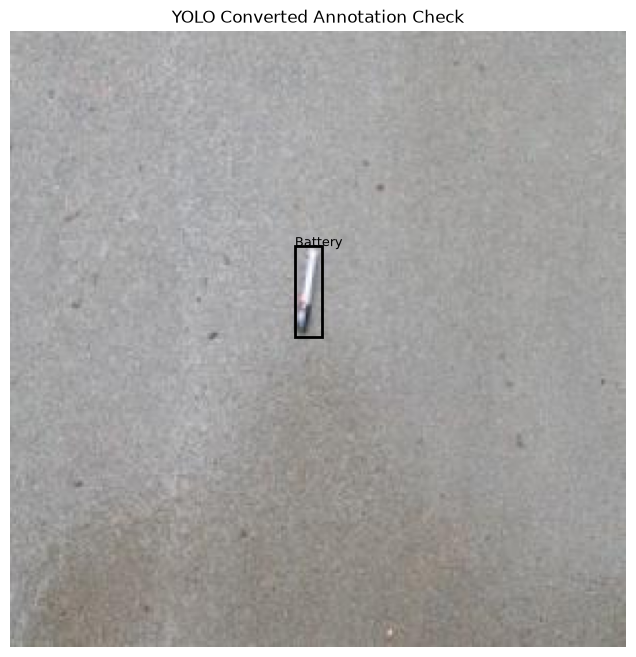

In [83]:
sample_image_path = (
    YOLO_DATASET_DIR
    / "images"
    / "train"
    / sample_filename
)

sample_label_path = (
    YOLO_DATASET_DIR
    / "labels"
    / "train"
    / f"{Path(sample_filename).stem}.txt"
)

print("Image:", sample_image_path)
print("Label:", sample_label_path)

print(
    "Image exists:",
    sample_image_path.exists()
)

print(
    "Label exists:",
    sample_label_path.exists()
)

if not sample_image_path.exists():
    raise FileNotFoundError(
        f"Generated image not found: {sample_image_path}"
    )

if not sample_label_path.exists():
    raise FileNotFoundError(
        f"Generated label not found: {sample_label_path}"
    )

image = Image.open(
    sample_image_path
).convert("RGB")

image_width, image_height = image.size

image_array = np.array(image)

plt.figure(
    figsize=(8, 8)
)

plt.imshow(
    image_array
)

label_lines = (
    sample_label_path
    .read_text(
        encoding="utf-8"
    )
    .splitlines()
)

for line in label_lines:

    if not line.strip():
        continue

    values = line.split()

    class_id = int(values[0])

    x_center = (
        float(values[1])
        * image_width
    )

    y_center = (
        float(values[2])
        * image_height
    )

    box_width = (
        float(values[3])
        * image_width
    )

    box_height = (
        float(values[4])
        * image_height
    )

    xmin = (
        x_center
        - box_width / 2
    )

    ymin = (
        y_center
        - box_height / 2
    )

    rectangle = plt.Rectangle(
        (xmin, ymin),
        box_width,
        box_height,
        fill=False,
        linewidth=2
    )

    plt.gca().add_patch(
        rectangle
    )

    plt.text(
        xmin,
        ymin,
        id_to_class[class_id],
        fontsize=9
    )

plt.title(
    "YOLO Converted Annotation Check"
)

plt.axis("off")

plt.show()


## 22. Load the YOLO Detection Model

We start with a small YOLO model as the baseline detector.

The training will use the GPU when CUDA is available.


In [84]:
MODEL_NAME = "yolo26n.pt"

model = YOLO(
    MODEL_NAME
)

print(
    "Model loaded:",
    MODEL_NAME
)


Model loaded: yolo26n.pt


## 23. Train the YOLO Baseline

Initial baseline settings:

```text
Image size : 640
Epochs     : 10
Batch size : 16
Device     : GPU 0
Workers    : 0
```

`workers=0` is intentionally used because this project is being run on Windows.


In [85]:
EPOCHS = 10
IMG_SIZE = 640
BATCH_SIZE = 16
DEVICE = 0

TRAIN_RUN_DIR = (
    ARTIFACTS_DIR
    / "fod_yolo_baseline"
)

results = model.train(
    data=str(DATA_YAML_PATH),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=0,
    project=str(ARTIFACTS_DIR),
    name="fod_yolo_baseline",
    exist_ok=True
)

print()
print("YOLO baseline training completed.")
print("Run directory:", TRAIN_RUN_DIR)


Ultralytics 8.4.174  Python-3.13.9 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Projects\AI Runway FOD Detection\data\processed\yolo_dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0

## 24. Locate the Best Trained Model

In [86]:
BEST_MODEL_SOURCE = (
    TRAIN_RUN_DIR
    / "weights"
    / "best.pt"
)

print(
    "Best model path:",
    BEST_MODEL_SOURCE
)

print(
    "Best model exists:",
    BEST_MODEL_SOURCE.exists()
)

if not BEST_MODEL_SOURCE.exists():

    raise FileNotFoundError(
        "best.pt was not created. "
        "Check the training output above."
    )


Best model path: D:\Projects\AI Runway FOD Detection\artifacts\fod_yolo_baseline\weights\best.pt
Best model exists: True


## 25. Load the Best Model for Evaluation

We reload `best.pt` so that validation and test inference use the best checkpoint produced during training.


In [87]:
best_model = YOLO(
    str(BEST_MODEL_SOURCE)
)

print(
    "Best model loaded successfully."
)


Best model loaded successfully.


## 26. Validate the Trained Detector

Important object-detection metrics include:

- Precision
- Recall
- mAP50
- mAP50-95

IoU is the overlap measure behind bounding-box evaluation.


In [88]:
validation_results = best_model.val(
    data=str(DATA_YAML_PATH),
    split="val",
    imgsz=IMG_SIZE,
    device=DEVICE
)

print(
    validation_results
)


Ultralytics 8.4.174  Python-3.13.9 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 120 layers, 2,380,881 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 145.977.1 MB/s, size: 11.8 KB)
val: Scanning D:\Projects\AI Runway FOD Detection\data\processed\yolo_dataset\labels\val.cache... 5059 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5059/5059 2.1Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 317/317 6.4it/s 49.3s0.1sss
                   all       5059       5176      0.995      0.992       0.99      0.899
       AdjustableClamp         82         82      0.996          1      0.995      0.907
      AdjustableWrench         74         74      0.969      0.973      0.975      0.877
               Battery        153        153          1          1      0.995      0.858
                  Bolt        528        528      0.997     

## 27. Run Predictions on Official Test Images

In [89]:
test_image_paths = sorted(
    (
        YOLO_DATASET_DIR
        / "images"
        / "test"
    ).glob("*.jpg")
)

sample_test_images = test_image_paths[:5]

print(
    "Test images available:",
    len(test_image_paths)
)

print(
    "Images selected for sample prediction:",
    len(sample_test_images)
)

predictions = best_model.predict(
    source=[
        str(path)
        for path in sample_test_images
    ],
    imgsz=IMG_SIZE,
    conf=0.25,
    device=DEVICE,
    save=True
)

print(
    "Prediction completed."
)


Test images available: 8429
Images selected for sample prediction: 5

0: 640x640 1 Battery, 5.6ms
1: 640x640 1 Battery, 5.6ms
2: 640x640 1 Battery, 5.6ms
3: 640x640 1 Battery, 5.6ms
4: 640x640 1 Battery, 5.6ms
Speed: 2.2ms preprocess, 5.6ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to D:\Projects\AI Runway FOD Detection\runs\detect\predict
Prediction completed.


## 28. Display Detection Results

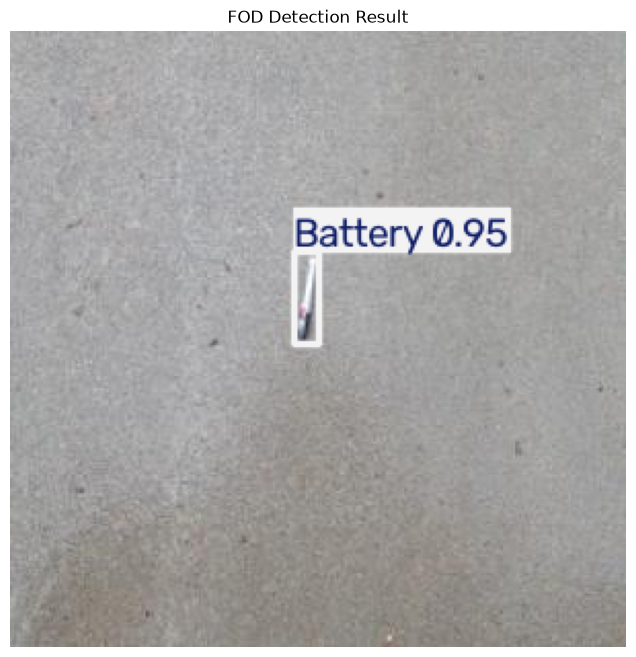

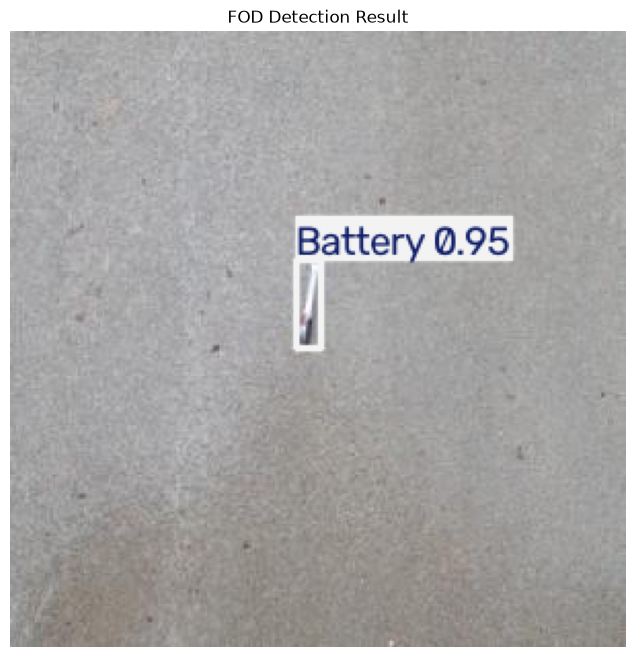

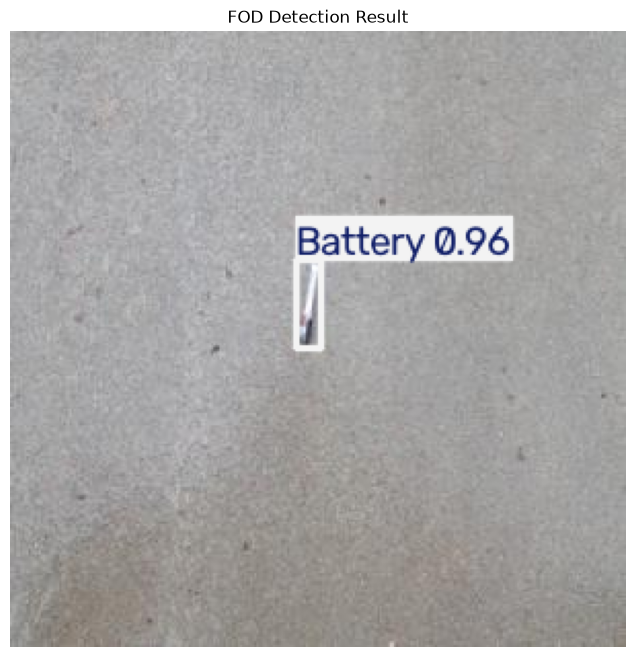

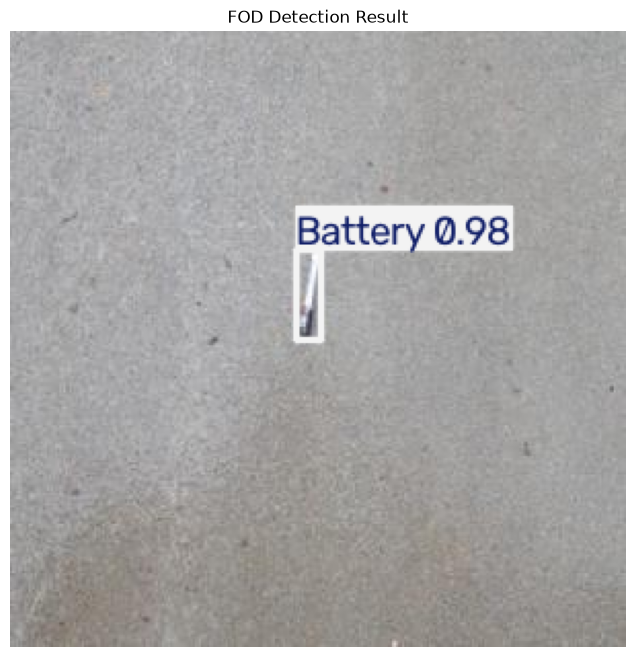

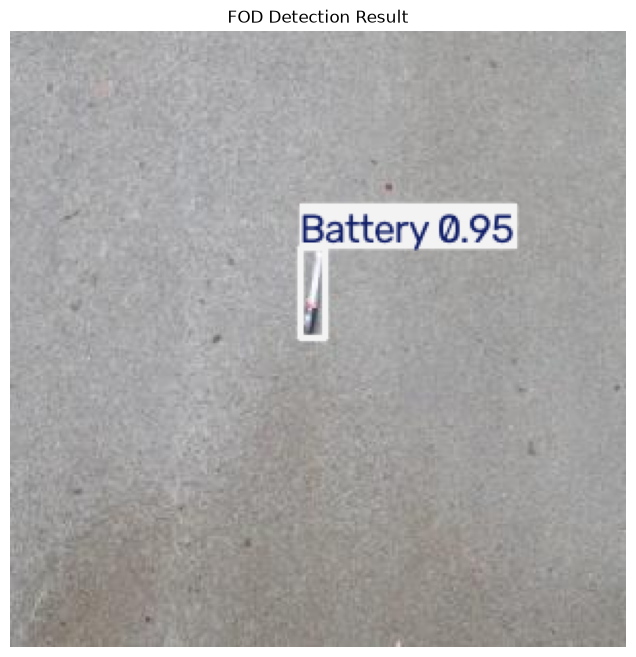

In [90]:
for result in predictions:

    plotted_image = result.plot()

    plt.figure(
        figsize=(8, 8)
    )

    # Ultralytics returns the plotted image in BGR format.
    plt.imshow(
        plotted_image[:, :, ::-1]
    )

    plt.title(
        "FOD Detection Result"
    )

    plt.axis("off")

    plt.show()


## 29. Inspect Raw Prediction Details

In [91]:
for result in predictions:

    print(
        "Image:",
        result.path
    )

    if result.boxes is None or len(result.boxes) == 0:

        print(
            "No detections"
        )

        print()
        continue

    boxes = result.boxes

    for index in range(
        len(boxes)
    ):

        class_id = int(
            boxes.cls[index].item()
        )

        confidence = float(
            boxes.conf[index].item()
        )

        coordinates = (
            boxes.xyxy[index]
            .tolist()
        )

        print(
            f"Class: {id_to_class[class_id]} | "
            f"Confidence: {confidence:.3f} | "
            f"Box: {coordinates}"
        )

    print()


Image: D:\Projects\AI Runway FOD Detection\data\processed\yolo_dataset\images\test\000008.jpg
Class: Battery | Confidence: 0.951 | Box: [138.41636657714844, 107.87116241455078, 150.5125732421875, 152.37060546875]

Image: D:\Projects\AI Runway FOD Detection\data\processed\yolo_dataset\images\test\000015.jpg
Class: Battery | Confidence: 0.951 | Box: [139.56991577148438, 111.08384704589844, 151.76937866210938, 154.27259826660156]

Image: D:\Projects\AI Runway FOD Detection\data\processed\yolo_dataset\images\test\000019.jpg
Class: Battery | Confidence: 0.964 | Box: [139.37124633789062, 111.51441955566406, 151.69558715820312, 154.498779296875]

Image: D:\Projects\AI Runway FOD Detection\data\processed\yolo_dataset\images\test\000030.jpg
Class: Battery | Confidence: 0.975 | Box: [139.56094360351562, 106.19551086425781, 151.80177307128906, 150.73399353027344]

Image: D:\Projects\AI Runway FOD Detection\data\processed\yolo_dataset\images\test\000040.jpg
Class: Battery | Confidence: 0.955 | Box

## 30. Save the Best Model into the Project `models` Folder

In [92]:
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_DESTINATION = (
    MODEL_DIR
    / "fod_yolo_baseline_best.pt"
)

shutil.copy2(
    BEST_MODEL_SOURCE,
    BEST_MODEL_DESTINATION
)

print(
    "Model saved to:",
    BEST_MODEL_DESTINATION
)

print(
    "Model size (MB):",
    round(
        BEST_MODEL_DESTINATION.stat().st_size
        / (1024 * 1024),
        2
    )
)


Model saved to: D:\Projects\AI Runway FOD Detection\models\fod_yolo_baseline_best.pt
Model size (MB): 5.16


## 31. Object Detection Pipeline Completed

We have now moved from:

```text
CNN / Image-level understanding
        ↓
Bounding-box annotations
        ↓
Object detection
        ↓
YOLO training
        ↓
Validation
        ↓
Test inference
        ↓
Saved detection model
```

The trained model predicts:

```text
FOD class
Bounding box
Confidence score
```

The next project step after this notebook is evaluation and error analysis.


## 32. Important Project Note

This is an industry-oriented portfolio prototype for computer-vision object detection.

It is **not** a certified airport safety system.

Real aviation deployment would require additional work such as:

- sensor/camera system integration
- real-time processing
- robust performance under changing weather and lighting
- false-alarm management
- latency and reliability testing
- operational validation
- safety certification and airport-specific requirements
